<a href="https://colab.research.google.com/github/zhangyingchengqi/Modern-Computer-Vision-with-PyTorch/blob/master/Chapter03/Scaling_the_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第三章第六节 缩放数据集以提升模型准确度

确保变量被限制在某个有限范围内的过程.  对每个输入值除以数据集中可能的最大值,将自变量的值限制为0和1之间的值.

In [1]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
import numpy as np
data_folder = '~/data/FMNIST' # This can be any directory you want
# to download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.7MB/s]


In [2]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()/255    # 除以像素最大值
        x = x.view(-1,28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

In [4]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl
from torch.optim import SGD
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        #nn.ReLU(),
        nn.Sigmoid(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    # call your model like any python function on your batch of inputs
    prediction = model(x)
    # compute loss
    batch_loss = loss_fn(prediction, y)
    # based on the forward pass in `model(x)` compute all the gradients of
    # 'model.parameters()'
    batch_loss.backward()
    # apply new-weights = f(old-weights, old-weight-gradients)
    # where "f" is the optimizer
    optimizer.step()
    # Flush memory for next batch of calculations
    optimizer.zero_grad()
    return batch_loss.item()
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    # since there's no need for updating weights, we might
    # as well not compute the gradients
    with torch.no_grad():
        # get the prediction matrix for a tensor of `x` images
        prediction = model(x)
    # compute if the location of maximum in each row coincides
    # with ground truth
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()
trn_dl = get_data()
model, loss_fn, optimizer = get_model()
losses, accuracies = [], []
for epoch in range(5):
    print(epoch)
    epoch_losses, epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)
    epoch_loss = np.array(epoch_losses).mean()
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)
    epoch_accuracy = np.mean(epoch_accuracies)
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

0
1
2
3
4


/tmp/ipython-input-2965093224.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


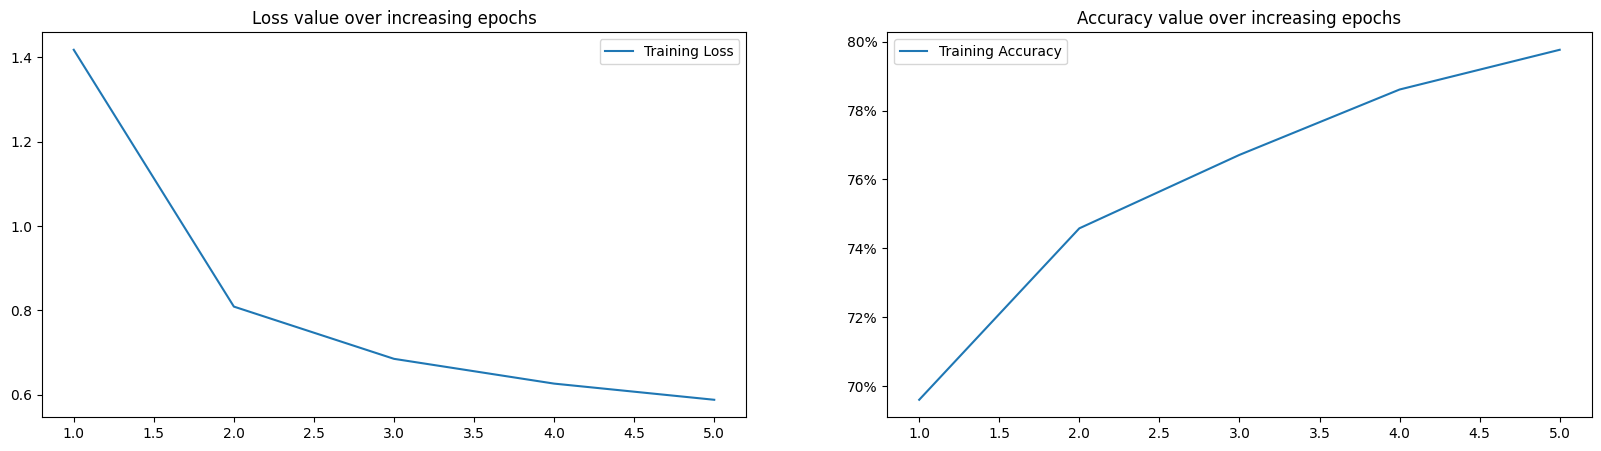

In [5]:
epochs = np.arange(5)+1
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()

对比前面的实验可以观察到: 准确度提升非常大. 那么为什么呢?


数据缩放（scaling / normalization / standardization）对模型准确性提升很大，主要原因是它直接影响了 优化过程、模型的数值稳定性，以及特征的相对重要性。

1. 数值范围不一致导致的优化困难: <br />
  如果一个特征的取值范围在 [0,1]，另一个在 [0,10000]，那么在计算梯度时，大数值特征会主导损失函数的变化。结果就是梯度方向被扭曲，优化器需要更长时间才能找到合适的最优点。缩放后，所有特征大致在相同范围（比如 0~1 或 均值0方差1），梯度下降的过程会更平滑，收敛更快。

2. 避免不同维度权重的不平衡:<br />
   假设你在训练一个线性模型: $y = w_1 x_1 + w_2 x_2 + b$ , 那么模型为了“平衡”输入，会学到：$𝑤1$很大（才能让小范围的$𝑥1$产生作用）, $𝑤2$很小（防止大范围的$𝑥2$爆炸）这样会导致参数学习效率差，而且可能让正则化失效。缩放后，模型能在更合理的参数范围里学习。

3. 对距离度量模型的影响:<br />
  在 KNN、SVM、K-means 这类依赖欧氏距离的模型中，如果特征没有缩放，大数值特征会完全主导距离计算

4. 梯度消失/爆炸问题:<br />
  在深度学习中，如果输入值过大，会造成 激活函数饱和（比如 Sigmoid 接近0或1），梯度几乎消失。如果输入差异过大，权重更新也可能不稳定，导致梯度爆炸。缩放输入可以让网络更好地在非线性区域工作，提升训练稳定性

5. 正则化效果: <br />
  L1 / L2 正则化会对权重大小进行惩罚。
  如果特征未缩放，不同特征需要非常不均衡的权重，正则化效果就会被破坏。缩放后，正则化能公平地约束权重。


# 另外, 如果激活函数用sigmoid的话，数据缩放与不缩放对模型效果的影响更大.

1. Sigmoid的特点:
  $\sigma(x) = \frac{1}{1+e^{-x}}, \quad \sigma'(x) = \sigma(x)(1-\sigma(x))$

  输出范围在(0,1),当|x|>5时，函数饱和，输出接近0或1,梯度几乎为0. 所以输入数据的数值大小，直接决定了是否会进入“饱和区”。

2. 没有缩放数据时:
   
   第一层是：nn.Linear(784, 1000)

   输入向量每个元素最大 255，总和量级可能达到几千。经过线性层加权后，得到的 z 往往非常大（比如几十到上百）。经过 Sigmoid 激活：输出几乎全是 0 或 1, 梯度 ≈ 0（几乎学不动）. 模型训练停滞，准确率可能接近随机水平（~10% for 10 classes）

3. 而缩放后:

   输入范围小，线性组合结果 $𝑧=𝑤𝑇𝑥+𝑏$ 分布在一个合理区间（大概在 [-5, 5] 内）. 经过 Sigmoid 激活后，大多数值落在 (0,1) 且梯度不为 0。
  模型能够有效反向传播，loss 会下降，准确率能显著提高（虽然通常还是比 ReLU 稍差）。

# 如果激活函数用 ReLU的话，分析如下.

1. ReLU的特性: $f(x) = \max(0, x), \quad f'(x) =
\begin{cases}
1 &   x \gt 0 \\
0 &   x \leq 0
\end{cases}$

   不会像 Sigmoid 一样在 $∣𝑥∣$ 很大时饱和、梯度消失。对大数值输入“相对宽容”，梯度始终为 1（只要激活在正区间）。因此 ReLU 对输入规模的敏感度比 Sigmoid 小很多。

2. 但如果不缩放输入（像素 0~255）时
   输入到第一层线性层，输出值 Z 可能很大（几千甚至上万）。
   经过 ReLU：大部分都会变成大正数，仍然可以反向传播。

   问题在于：
     1. 权重更新幅度会很大（因为梯度被输入值放大），需要依赖学习率来控制，否则会震荡甚至发散。
     2. 训练不稳定，loss 曲线可能起伏大。
     3. 部分小输入像素的信息可能被大值像素掩盖。

3. 反之，如果缩放输入（像素 0~1）时
   1. 输入和初始化权重在量级上更合理。
   2. 网络激活值分布比较均衡，不会全是超大数。
   3. 梯度下降更平稳，学习率 1e-2 也更合适。
   4. 准确率提升明显，收敛速度也会更快

# 第三章第七节 不同批大小的影响 varying batch size